In [18]:
from google.colab import files
uploaded = files.upload()

Saving Resume.csv to Resume.csv


In [19]:
import pandas as pd
df = pd.read_csv("Resume.csv")
print(df.shape)

(2484, 4)


In [20]:
import re

def clean_text(text):
    text = text.lower()                          # lowercase everything
    text = re.sub(r'\s+', ' ', text)              # collapse multiple spaces/newlines into one
    text = re.sub(r'[^a-z0-9\s]', ' ', text)      # remove punctuation/symbols
    text = text.strip()                           # remove leading/trailing whitespace
    return text

In [21]:
sample = df.iloc[0]["Resume_str"]
cleaned = clean_text(sample)
print(cleaned[:800])

hr administrator marketing associate hr administrator summary dedicated customer service manager with 15  years of experience in hospitality and customer service management  respected builder and leader of customer focused teams  strives to instill a shared  enthusiastic commitment to customer service  highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled multi tasker client relations specialist accomplishments missouri dot supervisor training certification certified by ihg in customer loyalty and marketing by segment hilton worldwide general manager training certification accomplished trainer for cross server hospitality systems such as hilton onq   micros opera pms   fidelio opera reservation system  or


In [22]:
df["cleaned_resume"] = df["Resume_str"].apply(clean_text)
df[["Resume_str", "cleaned_resume"]].head()

,Resume_str,cleaned_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versat...
2,HR DIRECTOR Summary Over 2...,hr director summary over 20 years experience i...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven and d...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


In [23]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [24]:
def tokenize_and_filter(text):
    tokens = word_tokenize(text)
    filtered = [word for word in tokens if word not in stop_words and len(word) > 2]
    return filtered

In [25]:
sample_tokens = tokenize_and_filter(cleaned)
print(sample_tokens[:50])

['administrator', 'marketing', 'associate', 'administrator', 'summary', 'dedicated', 'customer', 'service', 'manager', 'years', 'experience', 'hospitality', 'customer', 'service', 'management', 'respected', 'builder', 'leader', 'customer', 'focused', 'teams', 'strives', 'instill', 'shared', 'enthusiastic', 'commitment', 'customer', 'service', 'highlights', 'focused', 'customer', 'satisfaction', 'team', 'management', 'marketing', 'savvy', 'conflict', 'resolution', 'techniques', 'training', 'development', 'skilled', 'multi', 'tasker', 'client', 'relations', 'specialist', 'accomplishments', 'missouri', 'dot']


In [26]:
df["tokens"] = df["cleaned_resume"].apply(tokenize_and_filter)
df[["cleaned_resume", "tokens"]].head()

,cleaned_resume,tokens
0,hr administrator marketing associate hr admini...,"[administrator, marketing, associate, administ..."
1,hr specialist us hr operations summary versat...,"[specialist, operations, summary, versatile, m..."
2,hr director summary over 20 years experience i...,"[director, summary, years, experience, recruit..."
3,hr specialist summary dedicated driven and d...,"[specialist, summary, dedicated, driven, dynam..."
4,hr manager skill highlights hr skills hr depar...,"[manager, skill, highlights, skills, departmen..."


In [27]:
skill_list = [
    "python", "java", "sql", "excel", "javascript", "html", "css",
    "machine learning", "data analysis", "communication", "leadership",
    "project management", "customer service", "sales", "marketing",
    "accounting", "budgeting", "microsoft office", "teamwork",
    "problem solving", "aws", "cloud computing", "networking",
    "scheduling", "training", "recruiting", "financial reporting",
    "negotiation", "public speaking", "research"
]

In [28]:
def extract_skills(cleaned_text, skill_list):
    found = [skill for skill in skill_list if skill in cleaned_text]
    return found

In [29]:
sample_skills = extract_skills(cleaned, skill_list)
print(sample_skills)

['data analysis', 'leadership', 'customer service', 'sales', 'marketing', 'accounting', 'budgeting', 'aws', 'training']


In [30]:
df["skills_found"] = df["cleaned_resume"].apply(lambda x: extract_skills(x, skill_list))
df[["Category", "skills_found"]].head(10)

,Category,skills_found
0,HR,"[data analysis, leadership, customer service, ..."
1,HR,"[communication, project management, sales, mar..."
2,HR,"[excel, leadership, project management, custom..."
3,HR,"[excel, communication, customer service, train..."
4,HR,"[excel, leadership, project management, teamwo..."
5,HR,"[excel, microsoft office, training]"
6,HR,"[leadership, project management, customer serv..."
7,HR,"[communication, project management, customer s..."
8,HR,"[excel, communication, leadership, project man..."
9,HR,"[accounting, aws, scheduling, training, research]"


In [31]:
job_description = """
We are looking for a Data Analyst with strong skills in Python, SQL, and Excel.
The ideal candidate has experience in data analysis, machine learning, and communication.
Familiarity with cloud computing (AWS) and project management is a plus.
Strong problem solving and teamwork skills required.
"""

In [32]:
cleaned_job = clean_text(job_description)
print(cleaned_job)

we are looking for a data analyst with strong skills in python  sql  and excel  the ideal candidate has experience in data analysis  machine learning  and communication  familiarity with cloud computing  aws  and project management is a plus  strong problem solving and teamwork skills required


In [33]:
job_skills = extract_skills(cleaned_job, skill_list)
print("Required skills for this job:", job_skills)

Required skills for this job: ['python', 'sql', 'excel', 'machine learning', 'data analysis', 'communication', 'project management', 'teamwork', 'problem solving', 'aws', 'cloud computing']


In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [35]:
documents = [cleaned_job] + df["cleaned_resume"].tolist()

In [37]:
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(documents)

In [38]:
job_vector = tfidf_matrix[0:1]
resume_vectors = tfidf_matrix[1:]

similarity_scores = cosine_similarity(job_vector, resume_vectors)[0]

In [39]:
df["similarity_score"] = similarity_scores
df[["Category", "similarity_score"]].sort_values(by="similarity_score", ascending=False).head(10)

,Category,similarity_score
1762,ENGINEERING,0.168147
563,BUSINESS-DEVELOPMENT,0.160532
778,HEALTHCARE,0.160042
1218,CONSULTANT,0.158598
1091,SALES,0.149165
229,INFORMATION-TECHNOLOGY,0.147009
1303,DIGITAL-MEDIA,0.146782
1339,AUTOMOBILE,0.145329
1142,CONSULTANT,0.143308
331,INFORMATION-TECHNOLOGY,0.138339


In [40]:
def missing_skills(candidate_skills, job_skills):
    return [skill for skill in job_skills if skill not in candidate_skills]

In [41]:
df["missing_skills"] = df["skills_found"].apply(lambda skills: missing_skills(skills, job_skills))
df["skills_matched"] = df["skills_found"].apply(lambda skills: [s for s in job_skills if s in skills])

In [42]:
results = df[["ID", "Category", "similarity_score", "skills_matched", "missing_skills"]] \
            .sort_values(by="similarity_score", ascending=False) \
            .reset_index(drop=True)

results.index += 1  # so rank starts at 1, not 0
results.head(10)

,ID,Category,similarity_score,skills_matched,missing_skills
1,12011623,ENGINEERING,0.168147,"[python, sql, excel, machine learning, data an...","[communication, project management, teamwork, ..."
2,25397102,BUSINESS-DEVELOPMENT,0.160532,"[python, sql, excel, communication, problem so...","[machine learning, data analysis, project mana..."
3,26585242,HEALTHCARE,0.160042,"[sql, excel, data analysis, project management...","[python, machine learning, communication, team..."
4,21156767,CONSULTANT,0.158598,"[python, sql, machine learning, data analysis]","[excel, communication, project management, tea..."
5,24610685,SALES,0.149165,"[sql, excel, communication, project management]","[python, machine learning, data analysis, team..."
6,36434348,INFORMATION-TECHNOLOGY,0.147009,"[sql, communication, project management, probl...","[python, excel, machine learning, data analysi..."
7,42156237,DIGITAL-MEDIA,0.146782,"[python, sql, excel, project management]","[machine learning, data analysis, communicatio..."
8,18448085,AUTOMOBILE,0.145329,"[python, sql, excel, data analysis, problem so...","[machine learning, communication, project mana..."
9,30863060,CONSULTANT,0.143308,"[sql, excel, communication]","[python, machine learning, data analysis, proj..."
10,18067556,INFORMATION-TECHNOLOGY,0.138339,"[python, sql, excel, data analysis, project ma...","[machine learning, communication, teamwork, pr..."


In [43]:
top_candidate = results.iloc[0]
print(f"Top candidate: ID {top_candidate['ID']} ({top_candidate['Category']})")
print(f"Match score: {top_candidate['similarity_score']:.2f}")
print(f"Matched skills: {', '.join(top_candidate['skills_matched'])}")
print(f"Missing skills: {', '.join(top_candidate['missing_skills'])}")

Top candidate: ID 12011623 (ENGINEERING)
Match score: 0.17
Matched skills: python, sql, excel, machine learning, data analysis
Missing skills: communication, project management, teamwork, problem solving, aws, cloud computing


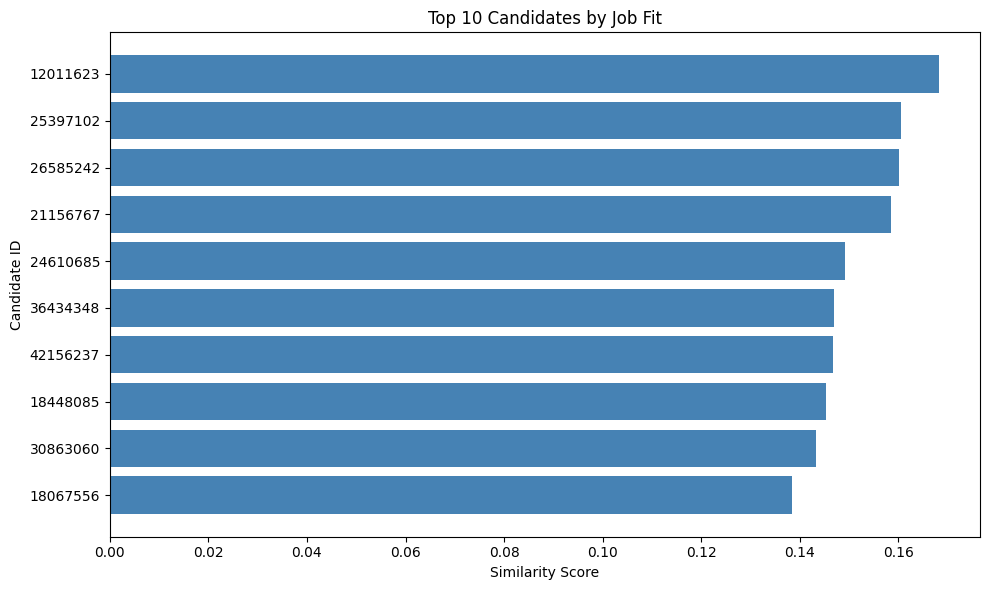

In [44]:
import matplotlib.pyplot as plt

top10 = results.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10["ID"].astype(str), top10["similarity_score"], color="steelblue")
plt.xlabel("Similarity Score")
plt.ylabel("Candidate ID")
plt.title("Top 10 Candidates by Job Fit")
plt.gca().invert_yaxis()  # highest score on top
plt.tight_layout()
plt.show()